# Παλινδρόμηση 

## 1. Imports

In [3]:
# Βασικές βιβλιοθήκες για επεξεργασία δεδομένων και γραφήματα
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Εργαλεία για διαχωρισμό και επεξεργασία δεδομένων
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Αλγόριθμοι για παλινδρόμηση
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor 
from sklearn.ensemble import RandomForestRegressor

# Metrics για την αξιολογηση των μοντέλων
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Για να χωράνε τα γραφήματα μέσα στο notebook 
%matplotlib inline

## 2. Loading and Description of Dataset

In [5]:
# Διαβάζουμε το Dataset#
df = pd.read_csv('data/world_cup_matches_clean.csv')
df.head() # Βλέπουμε τις 5 πρώτες γραμμές

,year,datetime,stage,stadium,city,home_team_name,home_team_goals,away_team_goals,away_team_name,win_conditions,...,referee,assistant_1,assistant_2,round_id,match_id,home_team_initials,away_team_initials,total_goals,goal_difference,half_time_total_goals
0,1930,13 Jul 1930 - 15:00,Group 1,Pocitos,Montevideo,France,4,1,Mexico,NaN,...,LOMBARDI Domingo (URU),CRISTOPHE Henry (BEL),REGO Gilberto (BRA),201,1096,FRA,MEX,5,3,3
1,1930,13 Jul 1930 - 15:00,Group 4,Parque Central,Montevideo,USA,3,0,Belgium,NaN,...,MACIAS Jose (ARG),MATEUCCI Francisco (URU),WARNKEN Alberto (CHI),201,1090,USA,BEL,3,3,2
2,1930,14 Jul 1930 - 12:45,Group 2,Parque Central,Montevideo,Yugoslavia,2,1,Brazil,NaN,...,TEJADA Anibal (URU),VALLARINO Ricardo (URU),BALWAY Thomas (FRA),201,1093,YUG,BRA,3,1,2
3,1930,14 Jul 1930 - 14:50,Group 3,Pocitos,Montevideo,Romania,3,1,Peru,NaN,...,WARNKEN Alberto (CHI),LANGENUS Jean (BEL),MATEUCCI Francisco (URU),201,1098,ROU,PER,4,2,1
4,1930,15 Jul 1930 - 16:00,Group 1,Parque Central,Montevideo,Argentina,1,0,France,NaN,...,REGO Gilberto (BRA),SAUCEDO Ulises (BOL),RADULESCU Constantin (ROU),201,1085,ARG,FRA,1,1,0


In [6]:
2.

2.0

In [7]:
# Βασικές πληροφορίες στηλών και τύπων δεδομένων
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 852 entries, 0 to 851
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   year                   852 non-null    int64  
 1   datetime               852 non-null    object 
 2   stage                  852 non-null    object 
 3   stadium                852 non-null    object 
 4   city                   852 non-null    object 
 5   home_team_name         852 non-null    object 
 6   home_team_goals        852 non-null    int64  
 7   away_team_goals        852 non-null    int64  
 8   away_team_name         852 non-null    object 
 9   win_conditions         65 non-null     object 
 10  attendance             850 non-null    float64
 11  half_time_home_goals   852 non-null    int64  
 12  half_time_away_goals   852 non-null    int64  
 13  referee                852 non-null    object 
 14  assistant_1            852 non-null    object 
 15  assist

In [8]:
#Ονόματα στηλών
df.columns 

Index(['year', 'datetime', 'stage', 'stadium', 'city', 'home_team_name',
       'home_team_goals', 'away_team_goals', 'away_team_name',
       'win_conditions', 'attendance', 'half_time_home_goals',
       'half_time_away_goals', 'referee', 'assistant_1', 'assistant_2',
       'round_id', 'match_id', 'home_team_initials', 'away_team_initials',
       'total_goals', 'goal_difference', 'half_time_total_goals'],
      dtype='object')

In [9]:
print("Μέγεθος dataset:", df.shape)

Μέγεθος dataset: (852, 23)


In [10]:
# Η Παλινδρόμηση θέλει αριθμητική μεταβλητή 
# Η στήλη 'attendance' είναι ιδανική επειδή μας δείχνει τον αριθμό των θεατών που παρευρέθηκαν σε κάθε παιχνίδι

df['attendance'].describe() # Βλέπουμε βασικά στατιστικά στοιχεία για τη στήλη



count       850.000000
mean      45164.800000
std       23485.249247
min        2000.000000
25%       30000.000000
50%       41579.500000
75%       61374.500000
max      173850.000000
Name: attendance, dtype: float64

In [11]:
# Ελέγχουμε πόσες κενές τιμές υπάρχουν στο attendance και καθαρισμός
print("Έλεγχος κενών τιμών:")
print(df['attendance'].isnull().sum())


Έλεγχος κενών τιμών:
2


In [12]:
# Αφαιρούμε τις κενές τιμές
df = df.dropna(subset=['attendance']).copy()
df = df.reset_index(drop=True)

In [13]:
# Ελέγχουμε ξανα το μέγεθος του dataset και τις κενές τιμές
print("Μέγεθος Dataset μετά τον καθαρισμό:", df.shape)

# Έλεγχος κενών τιμών στο 'attendance' μετα τον καθαρισμό
print(df['attendance'].isnull().sum())


Μέγεθος Dataset μετά τον καθαρισμό: (850, 23)
0


## Exploratory Data Analysis (EDA)

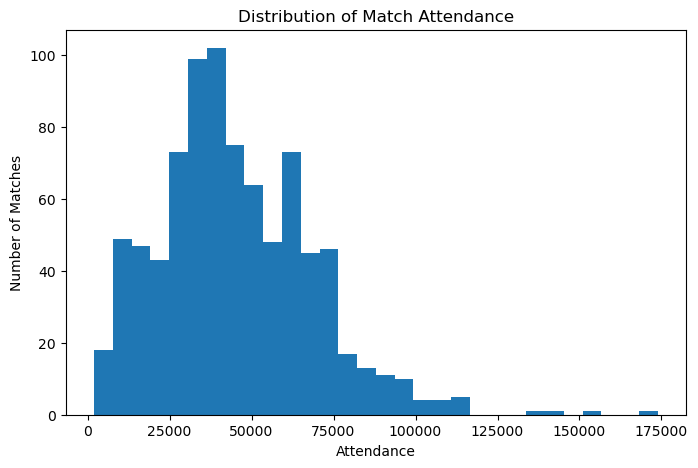

In [15]:
# Histogram για την κατανομή της προσέλευσης θεατών

plt.figure(figsize=(8, 5))
plt.hist(df['attendance'], bins=30)

plt.title('Distribution of Match Attendance')
plt.xlabel('Attendance')
plt.ylabel('Number of Matches')

plt.show()

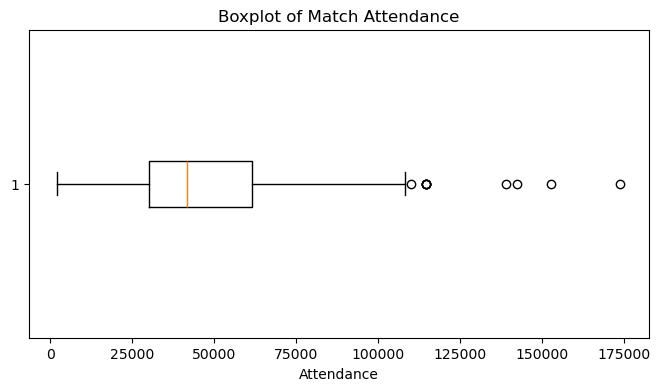

In [16]:
# Boxplot για να δούμε αν υπάρχουν ακραίες τιμές στο attendance

plt.figure(figsize=(8, 4))
plt.boxplot(df['attendance'], vert=False)

plt.title('Boxplot of Match Attendance')
plt.xlabel('Attendance')

plt.show()

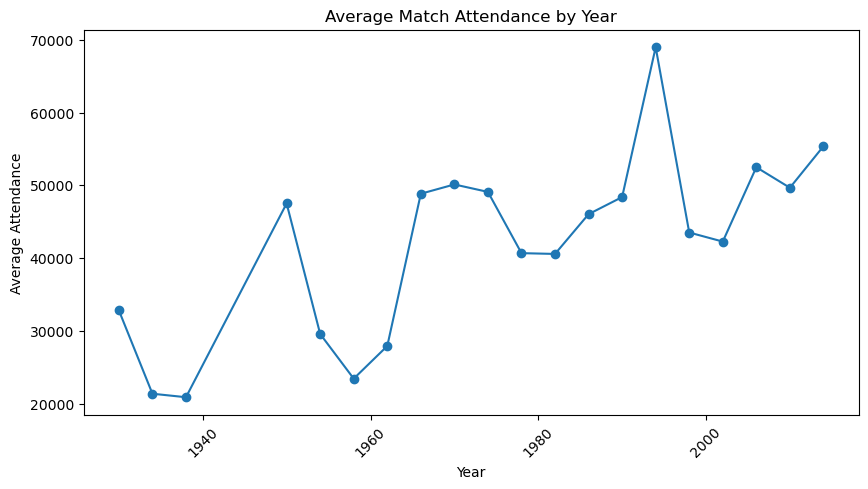

In [17]:
# Μέση προσέλευση θεατών ανά χρονιά

attendance_by_year = df.groupby('year')['attendance'].mean()

plt.figure(figsize=(10, 5))
plt.plot(attendance_by_year.index, attendance_by_year.values, marker='o')

plt.title('Average Match Attendance by Year')
plt.xlabel('Year')
plt.ylabel('Average Attendance')
plt.xticks(rotation=45)

plt.show()

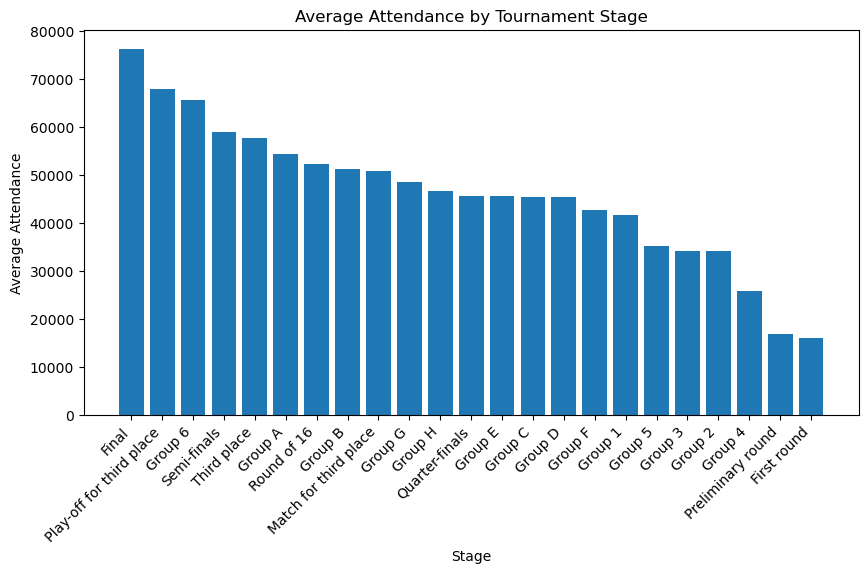

In [18]:
# Μέση προσέλευση ανά φάση της διοργάνωσης

attendance_by_stage = df.groupby('stage')['attendance'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(attendance_by_stage.index, attendance_by_stage.values)

plt.title('Average Attendance by Tournament Stage')
plt.xlabel('Stage')
plt.ylabel('Average Attendance')
plt.xticks(rotation=45, ha='right')

plt.show()

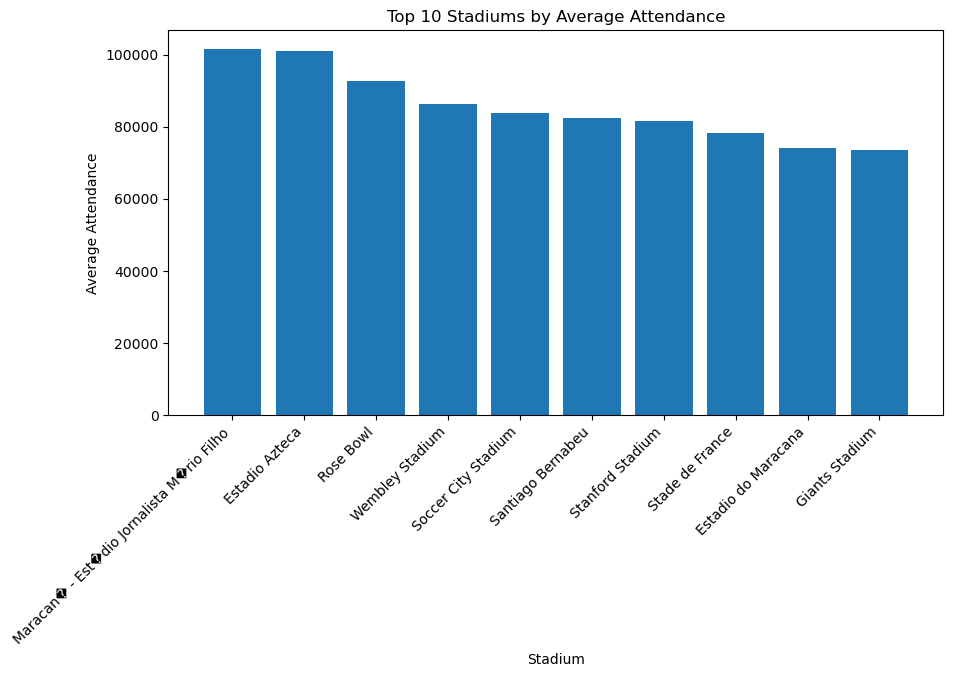

In [19]:
# Τα 10 στάδια με τη μεγαλύτερη μέση προσέλευση

top_stadiums = df.groupby('stadium')['attendance'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
plt.bar(top_stadiums.index, top_stadiums.values)

plt.title('Top 10 Stadiums by Average Attendance')
plt.xlabel('Stadium')
plt.ylabel('Average Attendance')
plt.xticks(rotation=45, ha='right')

plt.show()

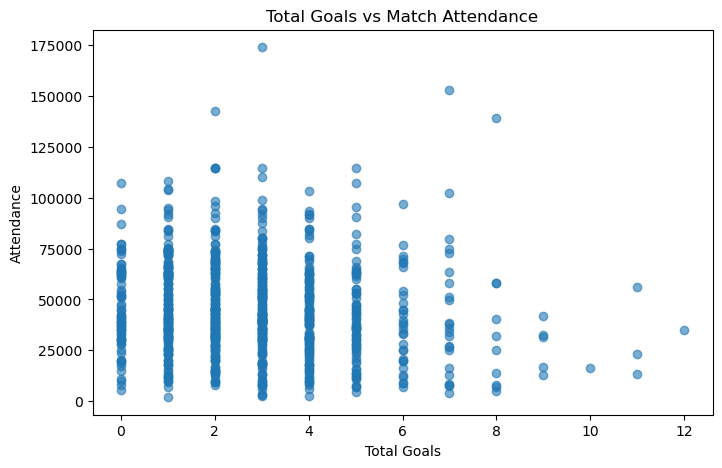

In [20]:
# Scatter plot για να δούμε τη σχέση μεταξύ συνολικών γκολ και προσέλευσης

plt.figure(figsize=(8, 5))
plt.scatter(df['total_goals'], df['attendance'], alpha=0.6)

plt.title('Total Goals vs Match Attendance')
plt.xlabel('Total Goals')
plt.ylabel('Attendance')

plt.show()

## 4. Descriptive Statistics

In [22]:
# Περιγραφικά στατιστικά για όλες τις αριθμητικές στήλες
df.describe()

,year,home_team_goals,away_team_goals,attendance,half_time_home_goals,half_time_away_goals,round_id,match_id,total_goals,goal_difference,half_time_total_goals
count,850.000000,850.000000,850.000000,850.000000,850.000000,850.000000,8.500000e+02,8.500000e+02,850.000000,850.000000,850.000000
mean,1985.021176,1.810588,1.022353,45164.800000,0.710588,0.429412,1.068626e+07,6.078489e+07,2.832941,1.512941,1.140000
std,22.431301,1.612125,1.088853,23485.249247,0.937885,0.691752,2.732359e+07,1.105805e+08,1.956620,1.439129,1.177098
min,1930.000000,0.000000,0.000000,2000.000000,0.000000,0.000000,2.010000e+02,2.500000e+01,0.000000,0.000000,0.000000
25%,1970.000000,1.000000,0.000000,30000.000000,0.000000,0.000000,2.620000e+02,1.188250e+03,1.000000,1.000000,0.000000
50%,1990.000000,2.000000,1.000000,41579.500000,0.000000,0.000000,3.370000e+02,2.184000e+03,3.000000,1.000000,1.000000
75%,2002.000000,3.000000,2.000000,61374.500000,1.000000,1.000000,2.497220e+05,4.395006e+07,4.000000,2.000000,2.000000
max,2014.000000,10.000000,7.000000,173850.000000,6.000000,5.000000,9.741060e+07,3.001865e+08,12.000000,9.000000,9.000000


In [23]:
# Ελέγχουμε όλες τις στήλες για κενές τιμές
missing_values = df.isnull().sum()

# Κρατάμε μόνο τις στήλες που έχουν έστω και ένα missing value
missing_values = missing_values[missing_values > 0]

missing_values

win_conditions    787
dtype: int64

In [24]:
# Βλέπουμε τους τύπους δεδομένων κάθε στήλης
df.dtypes

year                       int64
datetime                  object
stage                     object
stadium                   object
city                      object
home_team_name            object
home_team_goals            int64
away_team_goals            int64
away_team_name            object
win_conditions            object
attendance               float64
half_time_home_goals       int64
half_time_away_goals       int64
referee                   object
assistant_1               object
assistant_2               object
round_id                   int64
match_id                   int64
home_team_initials        object
away_team_initials        object
total_goals                int64
goal_difference            int64
half_time_total_goals      int64
dtype: object

## 5. Preprocessing and Train/Test Split

In [26]:
# Επιλογή σαν στόχο τη μεταβλητή 'attendance'
# ΚΑι επιλέγουμε τις υπόλοιπες στήλες που θα χρησιμοποιήσουμε για την πρόβλεψη των θεατών που παρευρέθηκαν σε παιχνίδι
target = 'attendance' 

features = [
    'year',
    'stage',
    'stadium',
    'city',
    'home_team_name',
    'away_team_name',
    'home_team_goals',
    'away_team_goals',
    'half_time_home_goals',
    'half_time_away_goals',
    'total_goals',
    'goal_difference',
    'half_time_total_goals'
]

x = df[features]
y = df[target]

print("Διαστάσεις στηλών:", x.shape)
print("Διαστάσεις στόχου:", y.shape)




Διαστάσεις στηλών: (850, 13)
Διαστάσεις στόχου: (850,)


In [27]:
# Βλέπουμε τις πρώτες γραμμές των features
x.head()

,year,stage,stadium,city,home_team_name,away_team_name,home_team_goals,away_team_goals,half_time_home_goals,half_time_away_goals,total_goals,goal_difference,half_time_total_goals
0,1930,Group 1,Pocitos,Montevideo,France,Mexico,4,1,3,0,5,3,3
1,1930,Group 4,Parque Central,Montevideo,USA,Belgium,3,0,2,0,3,3,2
2,1930,Group 2,Parque Central,Montevideo,Yugoslavia,Brazil,2,1,2,0,3,1,2
3,1930,Group 3,Pocitos,Montevideo,Romania,Peru,3,1,1,0,4,2,1
4,1930,Group 1,Parque Central,Montevideo,Argentina,France,1,0,0,0,1,1,0


In [28]:
# Βλέπουμε τις πρώτες τιμές του target
y.head()

0     4444.0
1    18346.0
2    24059.0
3     2549.0
4    23409.0
Name: attendance, dtype: float64

In [29]:
# Ελέγχουμε αν υπάρχουν κενές τιμές στα features
x.isnull().sum()

year                     0
stage                    0
stadium                  0
city                     0
home_team_name           0
away_team_name           0
home_team_goals          0
away_team_goals          0
half_time_home_goals     0
half_time_away_goals     0
total_goals              0
goal_difference          0
half_time_total_goals    0
dtype: int64

In [30]:
# Ξεχωρίζουμε τις στήλες σε αριθμητικές και κατηγορικές
numeric_features = [
    'year',
    'home_team_goals',
    'away_team_goals',
    'half_time_home_goals',           # Numeric
    'half_time_away_goals',
    'total_goals',
    'goal_difference',
    'half_time_total_goals'
]

categorical_features = [
    'stage',
    'stadium',
    'city',                          # Categorical
    'home_team_name',
    'away_team_name'
]

print(f"Αριθμητικές στήλες: {numeric_features}")
print(f"\nΚατηγορικές στήλες: {categorical_features}")

Αριθμητικές στήλες: ['year', 'home_team_goals', 'away_team_goals', 'half_time_home_goals', 'half_time_away_goals', 'total_goals', 'goal_difference', 'half_time_total_goals']

Κατηγορικές στήλες: ['stage', 'stadium', 'city', 'home_team_name', 'away_team_name']


In [31]:
# Διαχωρισμός Δεδομένων για εκπαίδευση και τεστ
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 10)
print(f"Διαστάσεις χαρακτηριστικών εκπαίδευσης: x_train: {x_train.shape} \nΔιαστάσεις χαρακτηριστικών ελέγχου: x_test: {x_test.shape} \nΔιαστάσεις στόχου εκπαίδευσης: y_train: {y_train.shape} \nΔιαστάσεις στόχου ελέγχου: y_test: {y_test.shape}")

Διαστάσεις χαρακτηριστικών εκπαίδευσης: x_train: (680, 13) 
Διαστάσεις χαρακτηριστικών ελέγχου: x_test: (170, 13) 
Διαστάσεις στόχου εκπαίδευσης: y_train: (680,) 
Διαστάσεις στόχου ελέγχου: y_test: (170,)


In [32]:
# Προεπεξεργασία αριθμητικών και κατηγορικών στηλών

# Pipeline για αριθμητικές στήλες
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pipeline για κατηγορικές στήλες
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Ενώνουμε τα δύο pipelines σε ένα preprocessing βήμα
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)
print("Το preprocessing pipeline δημιουργήθηκε με επιτυχία.")
print(f"Αριθμητικές στήλες: {len(numeric_features)} \nΚατηγορικές στήλες: {len(categorical_features)}")

Το preprocessing pipeline δημιουργήθηκε με επιτυχία.
Αριθμητικές στήλες: 8 
Κατηγορικές στήλες: 5


In [33]:
# Δοκιμαστική εφαρμογή του preprocessing στα training δεδομένα

x_train_processed = preprocessor.fit_transform(x_train)
x_test_processed = preprocessor.transform(x_test)

print("Διαστάσεις X_train πριν το preprocessing:", x_train.shape)
print("Διαστάσεις X_train μετά το preprocessing:", x_train_processed.shape)

print("Διαστάσεις X_test πριν το preprocessing:", x_test.shape)
print("Διαστάσεις X_test μετά το preprocessing:", x_test_processed.shape)

Διαστάσεις X_train πριν το preprocessing: (680, 13)
Διαστάσεις X_train μετά το preprocessing: (680, 512)
Διαστάσεις X_test πριν το preprocessing: (170, 13)
Διαστάσεις X_test μετά το preprocessing: (170, 512)


Μετά την προεπεξεργασία, ο αριθμός των γραμμών παρέμεινε ίδιος, ενώ ο αριθμός των στηλών αυξήθηκε από 13 σε 512. Αυτό συνέβη επειδή το One-Hot Encoding μετέτρεψε τις κατηγορικές μεταβλητές, όπως στάδιο, πόλη και ονόματα ομάδων, σε πολλές αριθμητικές στήλες.

## 6. Application of Algorithms

In [36]:
# Δημιουργία ενός dictionary με τα μοντέλα παλινδρόμησης που θα συγκρίνουμε
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(),
    'Decision Tree Regressor': DecisionTreeRegressor(random_state=42),
    'Random Forest Regressor': RandomForestRegressor(
        n_estimators=100,
        random_state=42
    )
}

# Δημιουργούμε μια κενή λίστα για να αποθηκεύσουμε τα αποτελέσματα κάθε μοντέλου
results = []

# Εκπαιδεύση και αξιολόγιση κάθε μοντέλου
for model_name, model in models.items():
    
    # Ενώνουμε την προεπεξεργασία που κάναμε μαζί με το μοντέλο στο ίδιο pipeline
    model_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    # Εκπαίδευση μοντέλου
    model_pipeline.fit(x_train, y_train)
    
    # Προβλέψεις στο test set
    y_pred = model_pipeline.predict(x_test)
    
    # Υπολογισμός metrics
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    # Πρόσθεση των αποτελεσμάτων στην κενή λίστα ώς dictionary
    results.append({
        'Model': model_name,
        'MAE': mae,
        'RMSE': rmse,
        'R2 Score': r2
    })

# Μετατροπή του dictionary σε DataFrame
results_df = pd.DataFrame(results)

# Εμφανίζουμε τα αποτελέσματα ταξινομημένα με βάση το R2 Score
results_df = results_df.sort_values(by='R2 Score', ascending=False)

results_df

,Model,MAE,RMSE,R2 Score
3,Random Forest Regressor,5938.483706,8887.056992,0.846675
1,Ridge Regression,7338.024813,10278.501769,0.794904
0,Linear Regression,8558.274568,11917.835843,0.724264
2,Decision Tree Regressor,6953.823529,12863.624688,0.678764


## 7. Evaluation

Το Random Forest Regressor ήταν το καλύτερο μοντέλο, επειδή είχε το μικρότερο MAE, το μικρότερο RMSE και το μεγαλύτερο R2 Score.

Αυτό σημαίνει ότι έκανε τις πιο κοντινές προβλέψεις στην πραγματική προσέλευση θεατών.

Το R2 Score 0.8467 δείχνει ότι το μοντέλο εξηγεί περίπου το 84.67% της μεταβλητότητας του attendance.

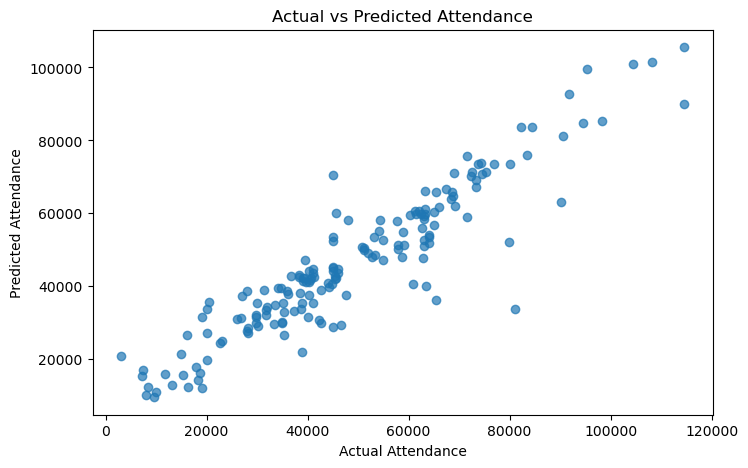

In [39]:
# Εκπαιδεύουμε ξανά το καλύτερο μοντέλο για να συγκρίνουμε πραγματικές και προβλεπόμενες τιμές

best_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42))
])

best_model.fit(x_train, y_train)

y_pred_best = best_model.predict(x_test)

plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred_best, alpha=0.7)

plt.title('Actual vs Predicted Attendance')
plt.xlabel('Actual Attendance')
plt.ylabel('Predicted Attendance')

plt.show()